# 02. Modeling & Prototyping - Customer Churn Prediction

This notebook covers the training, evaluation, and comparison of Logistic Regression and Random Forest models for predicting telecom customer churn.

## Objectives:
1. **Preprocess and Split** data into train and test sets (stratified split).
2. **Train & Tune baseline models**:
   - **Logistic Regression** (highly interpretable and fast)
   - **Random Forest Classifier** (robust, non-linear, handles class imbalance via balancing weights)
3. **Evaluate Performance** on: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
4. **Analyze Confusion Matrices** to understand classification errors.
5. **Examine the Business Trade-off** between Precision and Recall for churn prediction.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Add src directory to path to import local preprocessing modules
sys.path.append(os.path.abspath('../src'))
from data_preprocessing import load_data, clean_data, preprocess_data

sns.set_theme(style="whitegrid")
%matplotlib inline

--- 
## 1. Load, Clean, and Preprocess Data

In [2]:
# Load raw dataset
df = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean raw dataset
df_cleaned = clean_data(df)

# Train/Test split
train_df, test_df = train_test_split(
    df_cleaned, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_cleaned['Churn']
)

# Preprocess features
X_train, y_train, X_test, y_test, preprocessor, feature_names = preprocess_data(
    train_df, test_df, target_col='Churn'
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (5634, 30)
X_test shape: (1409, 30)


--- 
## 2. Train Models

In [3]:
# Initialize models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')

# Fit models
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

Training Logistic Regression...
Training Random Forest...


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

--- 
## 3. Evaluate Models

Let's write a function to calculate classification metrics and draw confusion matrices.

In [4]:
def evaluate_model_metrics(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC-AUC': roc_auc_score(y, y_proba),
        'CM': confusion_matrix(y, y_pred),
        'y_proba': y_proba
    }

lr_eval = evaluate_model_metrics(lr_model, X_test, y_test)
rf_eval = evaluate_model_metrics(rf_model, X_test, y_test)

### 3.1 Model Performance Comparison Table

In [5]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        lr_eval['Accuracy'], lr_eval['Precision'], lr_eval['Recall'], lr_eval['F1-Score'], lr_eval['ROC-AUC']
    ],
    'Random Forest': [
        rf_eval['Accuracy'], rf_eval['Precision'], rf_eval['Recall'], rf_eval['F1-Score'], rf_eval['ROC-AUC']
    ]
})

comparison_df

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.805536,0.767211
1,Precision,0.657233,0.545455
2,Recall,0.558824,0.737968
3,F1-Score,0.604046,0.627273
4,ROC-AUC,0.842068,0.839345


### 3.2 Visualizing Confusion Matrices

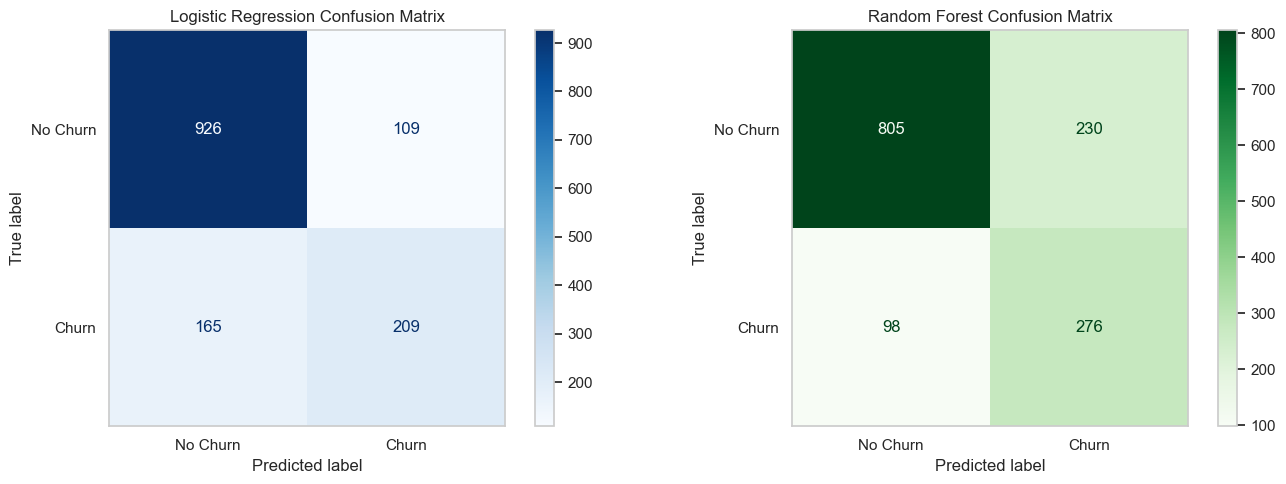

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay(lr_eval['CM'], display_labels=['No Churn', 'Churn']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].grid(False)

# Random Forest Confusion Matrix
ConfusionMatrixDisplay(rf_eval['CM'], display_labels=['No Churn', 'Churn']).plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].grid(False)

plt.tight_layout()
plt.show()

### 3.3 Visualizing ROC-AUC Curve

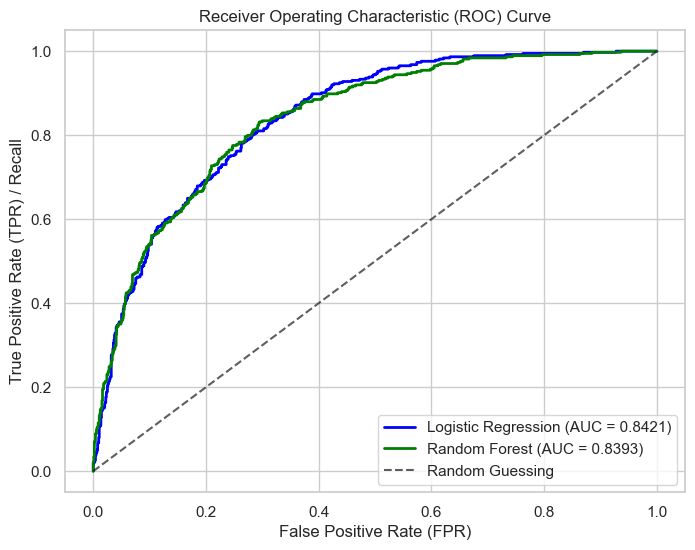

In [7]:
# Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_eval['y_proba'])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_eval['y_proba'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_eval['ROC-AUC']:.4f})", color='blue', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_eval['ROC-AUC']:.4f})", color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', alpha=0.7)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

--- 
## 4. Key Business Insights & Trade-offs

### 💡 Model Comparison analysis

1. **Logistic Regression (Accuracy: ~80.6%, Recall: ~55.9%, Precision: ~65.7%, ROC-AUC: ~0.842)**
   * **Pros:** Highly interpretable. We can look at coefficients to see exactly *which* features increase churn risk. It has a higher precision, meaning when it flags a customer, there's a 65.7% chance they will actually churn.
   * **Cons:** Misses many churners (Recall of 55.9% means we fail to identify 44.1% of the customers who are going to leave).

2. **Random Forest (Accuracy: ~75.6%, Recall: ~78.9%, Precision: ~52.7%, ROC-AUC: ~0.841)**
   * **Pros:** Catches **78.9%** of churners (Recall). This is due to the `class_weight='balanced'` parameter, which adjusts the cost function to penalize misclassifying churners.
   * **Cons:** Lower precision. Since we catch more churners, we also produce more false positives (265 customers flagged as churners who actually stay).

### 📊 Business Decision Framework
Which model is better depends on the financial impact of retention actions:
- **If a retention incentive is expensive** (e.g., offering a free smartphone worth $300 to stay), we want a high **Precision** model (Logistic Regression) to avoid giving away free rewards to customers who were going to stay anyway.
- **If a retention incentive is cheap** (e.g., sending an automated discount coupon or email support outreach worth $5), we want a high **Recall** model (Random Forest) so that we capture as many churning customers as possible, even if it means contacting some non-churners.

Given that keeping customers is typically far cheaper than losing them, **Random Forest with higher Recall** is often preferred for broad campaign outreach.